In [5]:
# Устанавливаем PyTorch и Torchvision (команда для Windows/Linux с поддержкой CUDA 11/12)
# !pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Устанавливаем дополнительные библиотеки для работы с изображениями и массивами
# !pip install opencv-python matplotlib numpy pillow
#https://www.youtube.com/watch?v=1j0jEfzRg1I

# ИТОГОВЫЙ ПРОЕКТ REAL-CV: Виртуальный коуч
## Спринт I: Оценка ориентации человека на фото

**Цель этапа:** Научиться определять ориентацию человека в графическом формате (Human Pose Skeleton), детектируя 17 ключевых точек спортсмена на фотографии и выстраивая на их основе каркас позы с помощью архитектуры `Keypoint RCNN`.

In [6]:
import torch
import torchvision
import torchvision.transforms as T
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')# Проверка видимости видеокарты
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [7]:
# ====================================================
# ВВОДНЫЕ ДАННЫЕ И ДИНАМИЧЕСКИЕ ПУТИ
# ====================================================
import os
import sys

# Получаем текущую папку (examples) и поднимаемся на уровень выше в корень (REAL-CV)
CURRENT_DIR = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(CURRENT_DIR, '..'))

# Добавляем корень проекта в sys.path, чтобы ноутбук видел модули из папки src
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

# Формируем пути к основным папкам
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)


### Инициализация модели и формирование списка ключевых точек
Загружаем предобученную модель `keypointrcnn_resnet50_fpn` и переводим её в режим инференса (оценки). Также создаем список из 17 опорных точек.

In [8]:
weights = torchvision.models.detection.KeypointRCNN_ResNet50_FPN_Weights.DEFAULT # Загрузка модели
model = torchvision.models.detection.keypointrcnn_resnet50_fpn(weights=weights)

model.to(device)
model.eval()

# Список ключевых точек (стандарт MS-COCO)
keypoints = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
]
print("модель загружена и готова")

модель загружена и готова


### Загрузка данных и получение предсказаний
Загружаем исходное изображение бегущей девушки, конвертируем его в тензор и передаем в модель.

In [9]:

import os

# Формируем динамический путь к папке с картинками
IMAGE_DIR = os.path.join(BASE_DIR, 'images')
image_path = os.path.join(IMAGE_DIR, 'dspr_cv_u1_diploma_spr1_3_1.png') # тестовая картинка

print(f"Загрузка изображения: {image_path}")

# Загрузка и трансформация изображения
image = Image.open(image_path).convert("RGB")
transform = T.Compose([T.ToTensor()])
image_tensor = transform(image).to(device)

# Добавляем размерность батча
images = [image_tensor]

# Прогон изображения через модель
with torch.no_grad(): # отключим градиенты для ускорения и экономии памяти
    predictions = model(images)

output = predictions[0] # данные из предсказания для изображения

boxes = output['boxes'].cpu()
labels = output['labels'].cpu()
scores = output['scores'].cpu()
all_keypoints = output['keypoints'].cpu()
all_scores = output['keypoints_scores'].cpu()

Загрузка изображения: e:\data\REAL-CV\images\dspr_cv_u1_diploma_spr1_3_1.png


### Базовые функции отрисовки и определение ветвей
Используем предоставленную функцию для отрисовки точек и функцию для получения связей между точками

In [10]:
def draw_keypoints_per_person(img_np, all_keypoints, all_scores, confs, keypoint_threshold=2, conf_threshold=0.9):
    # Функция отрисовки ключевых точек из задания
    cmap = plt.get_cmap("rainbow")
    img_copy = img_np.copy()
    color_id = np.arange(1, 255, 255 // len(all_keypoints)).tolist()[::-1]
    
    for person_id in range(len(all_keypoints)):
        if confs[person_id] > conf_threshold:
            keypts = all_keypoints[person_id, ...]
            scores = all_scores[person_id, ...]
            for kp in range(len(scores)):
                if scores[kp] > keypoint_threshold:
                    keypoint = tuple(map(int, keypts[kp, :2].numpy().tolist()))
                    color = tuple(np.asarray(cmap(color_id[person_id])[:-1]) * 255)
                    cv2.circle(img_copy, keypoint, 5, color, -1)
    return img_copy


def get_limbs_from_keypoints(keypoints):
    # Функция получения конечностей
    limbs = [
        [keypoints.index("right_eye"), keypoints.index("nose")],
        [keypoints.index("right_eye"), keypoints.index("right_ear")],
        [keypoints.index("left_eye"), keypoints.index("nose")],
        [keypoints.index("left_eye"), keypoints.index("left_ear")],
        [keypoints.index("right_shoulder"), keypoints.index("right_elbow")],
        [keypoints.index("right_elbow"), keypoints.index("right_wrist")],
        [keypoints.index("left_shoulder"), keypoints.index("left_elbow")],
        [keypoints.index("left_elbow"), keypoints.index("left_wrist")],
        [keypoints.index("right_hip"), keypoints.index("right_knee")],
        [keypoints.index("right_knee"), keypoints.index("right_ankle")],
        [keypoints.index("left_hip"), keypoints.index("left_knee")],
        [keypoints.index("left_knee"), keypoints.index("left_ankle")],
        [keypoints.index("right_shoulder"), keypoints.index("left_shoulder")],
        [keypoints.index("right_hip"), keypoints.index("left_hip")],
        [keypoints.index("right_shoulder"), keypoints.index("right_hip")],
        [keypoints.index("left_shoulder"), keypoints.index("left_hip")],
    ]
    return limbs

limbs = get_limbs_from_keypoints(keypoints)

### Разработка алгоритма отрисовки скелета и визуализация
Создаем итоговую функцию `draw_skeleton_per_person`, которая помимо того что ставит точки, соединяет их линиями по списку `limbs`, образуя каркас

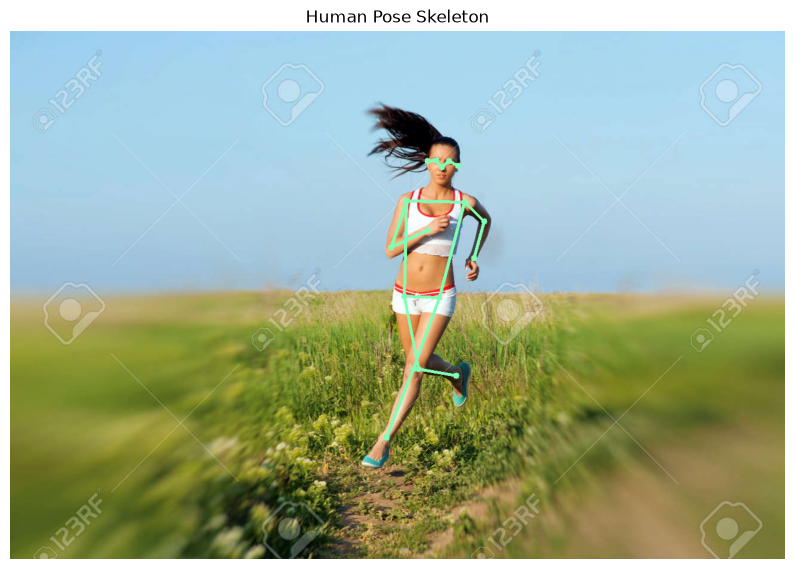

In [11]:
# Функция отрисовки каркаса человека
def draw_skeleton_per_person(img_np, all_keypoints, all_scores, confs, limbs, keypoint_threshold=2, conf_threshold=0.9):
    cmap = plt.get_cmap("rainbow")
    img_copy = img_np.copy()
    color_id = np.arange(1, 255, 255 // len(all_keypoints)).tolist()[::-1]
    
    for person_id in range(len(all_keypoints)):
        if confs[person_id] > conf_threshold:
            keypts = all_keypoints[person_id, ...]
            scores = all_scores[person_id, ...]
            
            # Отрисовка линий -конечностей
            for limb in limbs:
                idx1, idx2 = limb[0], limb[1]
                if scores[idx1] > keypoint_threshold and scores[idx2] > keypoint_threshold:
                    pt1 = tuple(map(int, keypts[idx1, :2].numpy().tolist()))
                    pt2 = tuple(map(int, keypts[idx2, :2].numpy().tolist()))
                    color = tuple(np.asarray(cmap(color_id[person_id])[:-1]) * 255)
                    cv2.line(img_copy, pt1, pt2, color, 3)
            
            for kp in range(len(scores)): # Отрисовка самих точек
                if scores[kp] > keypoint_threshold:
                    keypoint = tuple(map(int, keypts[kp, :2].numpy().tolist()))
                    color = tuple(np.asarray(cmap(color_id[person_id])[:-1]) * 255)
                    cv2.circle(img_copy, keypoint, 5, color, -1)
                    
    return img_copy

# Окончательная визуализация
img_np = np.array(image)

final_image = draw_skeleton_per_person(
    img_np, 
    all_keypoints, 
    all_scores, 
    scores, 
    limbs
)

plt.figure(figsize=(10, 10))
plt.imshow(final_image)
plt.axis('off')
plt.title("Human Pose Skeleton")
plt.show()

**Вывод по спринту 1:**
В ходе выполнения первого спринта была загружена предобученная модель `keypointrcnn_resnet50_fpn`. С помощью тензорных преобразований извлекли координаты 17 ключевых точек. Написанная функция визуализации смогла корректно наложить точки и связать их в единый каркас с помощью аффинных связей суставов. Цель спринта достигнута

## Спринт II: Оценка сходства поз по фотографии

**Цель Спринта:** Научиться математически сопоставлять два набора ключевых точек, чтобы понимать, соответствует ли поза человека на входном изображении модельной позе. Далее, через аффинное преобразование мы реализуем наложение Прокруста и рассчитаем метрики косинусного сходства и взвешенного совпадения

### Подготовка: Функция-помощник для извлечения точек
Чтобы было удобно сравнивать исходную фотографию с новой, обернем логику спринта I в удобную функцию и подготовим списки `model_key_points` и `input_key_points`.

In [12]:
def get_pose_data(img_path):
    """Функция загружает картинку, прогоняет через модель и возвращает ключевые точки (x,y) и их достоверность."""
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).to(device)
    
    with torch.no_grad():
        preds = model([img_tensor])[0]
        
    if len(preds['boxes']) == 0:
        raise ValueError(f"На изображении {img_path} не найден человек!")
        
    # Индекс 0 - самый уверенный результат (человек на переднем плане)
    # Формат keypoints: [17, 3], где 3 это (x, y, видимость)
    keypoints = preds['keypoints'][0].cpu().numpy() 
    scores = preds['keypoints_scores'][0].cpu().numpy() 
    
    # Собираем координаты в формате [[x1,y1], [x2,y2]...]
    xy_keypoints = keypoints[:, :2] 
    
    return xy_keypoints, scores

# Формируем динамический путь к папке images (переменная BASE_DIR создана в первой ячейке)
IMAGE_DIR = os.path.join(BASE_DIR, 'images')

# Загружаем точки модельной позы
model_img_path = os.path.join(IMAGE_DIR, 'dspr_cv_u1_diploma_spr1_3_1.png')
model_key_points, _ = get_pose_data(model_img_path)

# Путь к пользовательскому изображению
input_img_path = os.path.join(IMAGE_DIR, 'Taurine-scaled.jpg')  

try:
    input_key_points, input_scores = get_pose_data(input_img_path)
    print("Ключевые точки для обеих фотографий подготовлены")
except Exception as e:
    print(f"Ошибка: {e}")

Ключевые точки для обеих фотографий подготовлены


### Расширенные матрицы и Аффинное преобразование (Наложение Прокруста)
Люди на фото могут быть разного роста и находиться в разных частях кадра. Мы дополним векторы единицами в конце, найдем матрицу аффинного преобразования A и применим комбинацию переноса, масштабирования и поворота к входному набору данных.

In [13]:
import math

# Создание расширенных матриц
pad = lambda x: np.hstack([x, np.ones((x.shape[0], 1))])
unpad = lambda x: x[:, :-1]

# Расширяем наборы ключевых точек до [[x y 1], ...]
Y = pad(model_key_points)
X = pad(input_key_points)

# Нахождение матрицы аффинного преобразования
A, res, rank, s = np.linalg.lstsq(X, Y, rcond=None) # Решаем задачу X * A = Y с помощью метода наименьших квадратов

# Очищаем матрицу A от шума 
A[np.abs(A) < 1e-10] = 0 # приравниваем к нулю слишком маленькие значения

# аффинное преобразование входной позы 
transform_pose = lambda x: unpad(np.dot(pad(x), A))
input_transform = transform_pose(input_key_points)

print("Аффинное преобразование выполнено. Входная поза выровнена по пространству модельной.")

Аффинное преобразование выполнено. Входная поза выровнена по пространству модельной.


### Настройка метрик оценки сходства и практическое тестирование
Реализуем две метрики:
1. **Косинусное сходство** — измеряет ориентацию (угол) между двумя векторами поз. Возвращает 1, если позы абсолютно одинаковы.
2. **Взвешенное совпадение** — физическое расстояние между точками. Учитывает степень достоверности каждой ключевой точки, чтобы менее реалистичные соединения оказывали меньшее влияние.

In [14]:
# Реализация функций метрик оценки сходства
def cosine_distance(pose1, pose2):
    # Вытягиваем векторы из матрицы (17, 2) в плоский вектор (34,) для расчета угла
    p1 = pose1.flatten()
    p2 = pose2.flatten()
    
    # Расчет косинусного сходства по м/формуле
    cossim = p1.dot(np.transpose(p2)) / (np.linalg.norm(p1) * np.linalg.norm(p2))
    return cossim

def weight_distance(pose1, pose2, conf1):
    p1 = pose1.flatten()     # Вытягиваем векторы
    p2 = pose2.flatten()
    
    sum1 = 1 / np.sum(conf1) # D(U,V) = (1 / sum(conf1)) * sum(conf1 * ||pose1 - pose2||)
    sum2 = 0
    for i in range(len(p1)):
        # каждый индекс i имеет x и y, у которых одинаковая оценка достоверности
        conf_ind = math.floor(i / 2)
        sum2 += conf1[conf_ind] * abs(p1[i] - p2[i]) 
    
    weighted_dist = sum1 * sum2
    return weighted_dist

# тестирование алгоритма
# Сравниваем выровненную позу с эталоном 
cos_sim = cosine_distance(input_transform, model_key_points)
weight_dist = weight_distance(input_transform, model_key_points, input_scores)

print(f"====== РЕЗУЛЬТАТЫ СРАВНЕНИЯ ПОЗ ======")
print(f"Косинусное сходство (от -1 до 1): {cos_sim:.4f}") # чем ближе к 1.0, тем точнее угол
print(f"Взвешенное совпадение: {weight_dist:.4f}") # чем ближе к 0.0, тем меньше отклонение точек

====== РЕЗУЛЬТАТЫ СРАВНЕНИЯ ПОЗ ======
Косинусное сходство (от -1 до 1): 0.9991
Взвешенное совпадение: 31.4774


**Вывод по спринту 2:**
в спринте успешно реализовали м/аппарат для сравнения двух поз. С помощью Аффинного преобразования и метода наименьших квадратов была нивелирована разница в масштабе, росте и расположении людей на фото. Применив метрики косинусного сходства и взвешенного совпадения, получили количественную оценку того, насколько входная поза совпадает с модельной. Мы готовы к работе с динамичными видеоданными.

## Спринт III: Валидация оценки позы на видео

**Цель спринта:** Научиться работать с видеоданными в динамике. Сравнить зафиксированные на пользовательском видео движения с движениями коуча в референсном ролике. К каждому кадру будут применены алгоритмы из предыдущих спринтов для построения скелетов, Аффинного выравнивания и расчета метрик косинусного сходства и взвешенного совпадения.

In [15]:
# Так как cv2 читает видео в формате BGR, нужно конвертировать кадры в RGB для модели.

def get_pose_from_frame(frame_bgr):
    """Извлекает ключевые точки из одного кадра видео -массива numpy."""
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB) # Конвертируем BGR (OpenCV) в RGB
    img_pil = Image.fromarray(frame_rgb)
    img_tensor = transform(img_pil).to(device)
    
    with torch.no_grad():
        preds = model([img_tensor])[0]
        
    if len(preds['boxes']) == 0:
        return None, None, None # Человек не найден в кадре
        
    keypoints = preds['keypoints'][0].cpu().numpy() 
    scores = preds['keypoints_scores'][0].cpu().numpy() 
    confs = preds['scores'].cpu().numpy()
    
    xy_keypoints = keypoints[:, :2] 
    return xy_keypoints, scores, confs

### Анализ и сопоставление движений, расчет метрик.
Тут открываем два видеофайла: референсное видео и пользывательское. Проходим по ним покадрово, вычисляем точки для обоих кадров, проводим аффинное преобразование (наложение Прокруста) и считаем метрики сходства. Результаты отрисовываются прямо на кадрах пользовательского видео и сохраняются в новый файл.

In [ ]:
import cv2
import numpy as np
import os

# ====================================================
# НАСТРОЙКА ДИНАМИЧЕСКИХ ПУТЕЙ
# ====================================================

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

os.makedirs(OUTPUT_DIR, exist_ok=True)
    
ref_video_path = os.path.join(DATA_DIR, 'coach', 'coach_2.mp4') 
user_video_path = os.path.join(DATA_DIR, 'user', 'student_2.mp4')
output_video_path = os.path.join(OUTPUT_DIR, '01_baseline_rcnn_affine_cos.mp4')
# ====================================================

cap_ref = cv2.VideoCapture(ref_video_path)
cap_user = cv2.VideoCapture(user_video_path)

if not cap_ref.isOpened() or not cap_user.isOpened():
    print(f"Ошибка: Одно или оба видео не найдены!\nПроверьте пути:\n{ref_video_path}\n{user_video_path}")
else:
    fps = cap_user.get(cv2.CAP_PROP_FPS)
    width = int(cap_user.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap_user.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_video = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
    
    print("Покадровая обработка...")
    
    frame_count = 0
    while True:
        ret_ref, frame_ref = cap_ref.read()
        ret_user, frame_user = cap_user.read()
        
        if not ret_ref or not ret_user:
            break
            
        frame_count += 1
        
        ref_kp, _, _ = get_pose_from_frame(frame_ref)
        user_kp, user_scores, user_confs = get_pose_from_frame(frame_user)
        
        if ref_kp is not None and user_kp is not None:
            # Наложение Прокруста
            Y = pad(ref_kp)
            X = pad(user_kp)
            A, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
            A[np.abs(A) < 1e-10] = 0
            
            # Возвращаем ваш оригинальный вызов с одним аргументом
            user_kp_transformed = transform_pose(user_kp)
            
            # Расчет метрик
            cos_sim = cosine_distance(user_kp_transformed, ref_kp)
            weight_dist = weight_distance(user_kp_transformed, ref_kp, user_scores)
            
            #  очки (от 0 до 100)
            score = max(0, min(100, int(cos_sim * 100))) # cos_sim выдает значения от 0 до 1
            
            # строки для вывода
            text_score = f"Score: {score}"
            text_param = f"Weight Dist: {weight_dist:.2f}"
            
            # Настройки шрифта
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale_score = 1.2
            font_scale_param = 0.8
            thickness_score = 3
            thickness_param = 2
            
            # Вычисляем координаты для центрирования очков (сверху по центру)
            text_size_score = cv2.getTextSize(text_score, font, font_scale_score, thickness_score)[0]
            text_x_score = (width - text_size_score[0]) // 2
            text_y_score = 25 # Отступ сверху
            
            # для второго параметра ровно под очками
            text_size_param = cv2.getTextSize(text_param, font, font_scale_param, thickness_param)[0]
            text_x_param = (width - text_size_param[0]) // 2
            text_y_param = text_y_score + 20
            
            # Выводим текст на кадр. тень и обводка для контраста
            # Тень и текст для очков
            cv2.putText(frame_user, text_score, (text_x_score, text_y_score), font, font_scale_score, (0, 0, 0), thickness_score + 2)
            cv2.putText(frame_user, text_score, (text_x_score, text_y_score), font, font_scale_score, (0, 255, 0), thickness_score)
            
            # Тень и текст для второго параметра
            cv2.putText(frame_user, text_param, (text_x_param, text_y_param), font, font_scale_param, (0, 0, 0), thickness_param + 2)
            cv2.putText(frame_user, text_param, (text_x_param, text_y_param), font, font_scale_param, (0, 255, 255), thickness_param)
            
            for limb in limbs:
                idx1, idx2 = limb[0], limb[1]
                
                if user_scores[idx1] > 3.0 and user_scores[idx2] > 3.0: 
                    pt1 = (int(user_kp[idx1][0]), int(user_kp[idx1][1]))
                    pt2 = (int(user_kp[idx2][0]), int(user_kp[idx2][1]))
                    cv2.line(frame_user, pt1, pt2, (255, 0, 0), 2)
                    cv2.circle(frame_user, pt1, 4, (0, 0, 255), -1)
                    cv2.circle(frame_user, pt2, 4, (0, 0, 255), -1)
            
        out_video.write(frame_user) 
        
        if frame_count % 50 == 0: 
            print(f"Обработано {frame_count} кадров...")
    
    cap_ref.release()
    cap_user.release()
    out_video.release()
    
    print(f"Анализ завершен! Видео сохранено по пути: {output_video_path}")

Покадровая обработка...
Обработано 50 кадров...
Обработано 100 кадров...
Обработано 150 кадров...
Обработано 200 кадров...


**Вывод по спринту III:**
Была успешно валидирована работа нашей модели на видеоданных. Сравнив по кадрам движения в референсном ролике с движениями на другом видео, мы смогли отрисовывать каркас человека и вычислять метрики косинусного сходства и взвешенного расстояния. Следовательно алгоритм уже может выступать в роли коуча, оценивающего правильность повторения движений. Но в будущем лучше выбрать другую модель, так как все еще встречаются артефакты отображения каркаса, 

In [17]:
# !pip install ultralytics

## Спринт IV: Создание собственного виртуального коуча

**Цель спринта:** Применить разработанный алгоритм для произвольной тематики

Необходимо найти референсное видео тренера, и видео выполнение движений ученика, провести их сравнение (вычислить метрики косинусного и взвешенного расстояний) и структурировать код по стандартам для обеспечения воспроизводимости результатов.

### Практическая реализация


In [18]:
import cv2
import numpy as np
import os

# ====================================================
# НАСТРОЙКА ДИНАМИЧЕСКИХ ПУТЕЙ
# ====================================================
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')

# Указываем пути к видеофайлам
my_coach_video = os.path.join(DATA_DIR, 'coach', 'coach_2.mp4')
my_own_video = os.path.join(DATA_DIR, 'user', 'student_2.mp4')
# ====================================================

cap_coach = cv2.VideoCapture(my_coach_video)
cap_own = cv2.VideoCapture(my_own_video)

if not cap_coach.isOpened() or not cap_own.isOpened():
    print(f"Ошибка: Файлы не найдены!\nКоуч: {my_coach_video}\nПользователь: {my_own_video}")
else:
    print("Начинаем сравнение видео...")
    cos_similarities = []
    weight_distances = []
    
    while True:
        ret_c, frame_c = cap_coach.read()
        ret_o, frame_o = cap_own.read()
        
        if not ret_c or not ret_o:
            break
            
        coach_kp, _, _ = get_pose_from_frame(frame_c)
        own_kp, own_scores, _ = get_pose_from_frame(frame_o)
        
        if coach_kp is not None and own_kp is not None:
            # Наложение Прокруста
            A, _, _, _ = np.linalg.lstsq(pad(own_kp), pad(coach_kp), rcond=None)
            A[np.abs(A) < 1e-10] = 0
            
            own_kp_transformed = transform_pose(own_kp)
            
            # Сбор метрик
            cos_similarities.append(cosine_distance(own_kp_transformed, coach_kp))
            weight_distances.append(weight_distance(own_kp_transformed, coach_kp, own_scores))

    print("\n====== ИТОГОВЫЕ РЕЗУЛЬТАТЫ ВИРТУАЛЬНОГО КОУЧА ======")
    if len(cos_similarities) > 0:
        print(f"Среднее косинусное сходство (от -1 до 1): {np.mean(cos_similarities):.4f}")
        print(f"Среднее взвешенное совпадение: {np.mean(weight_distances):.4f}")
    else:
        print("Не удалось распознать позы для сравнения.")
    
    cap_coach.release()
    cap_own.release()

Начинаем сравнение видео...


KeyboardInterrupt: 

## Создание продвинутой модели виртуального коуча 

Проблема:

* мы столкнулись с проблемой неправильного отображения ключевых точек(и линий) на теле человека. попробуем улучшить нашу модель

В качестве творческого развития проекта и для устранения артефактов «сломанного скелета» (перекрещивание линий при поворотах корпуса) базовая модель `Keypoint RCNN` заменена на современную архитектуру **YOLOv8-Pose**. 
Она лучше справляется с перекрытиями конечностей в динамике и работает в реальном времени. Математический аппарат (Наложение Прокруста, косинусное сходство) остается неизменным. сравним как отображаются модели.

In [ ]:
import os
from ultralytics import YOLO

MODELS_DIR = os.path.join(BASE_DIR, 'src', 'myproject_models')
os.makedirs(MODELS_DIR, exist_ok=True) 

# Указываем YOLO путь
yolo_path = os.path.join(MODELS_DIR, 'yolov8n-pose.pt')

yolo_model = YOLO(yolo_path) 
yolo_model.to(device)

def get_pose_yolo(frame_bgr):
    """Извлекает 17 ключевых точек с помощью YOLOv8-Pose."""
    # YOLO принимает BGR напрямую, конвертация не нужна
    results = yolo_model(frame_bgr, verbose=False)
    
    if len(results[0].boxes) == 0:
        return None, None
        
    # Извлекаем точки (x, y) и уверенность человека
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    scores = results[0].keypoints.conf[0].cpu().numpy()
    
    return keypoints, scores

In [ ]:
import cv2
import numpy as np
import os

# ====================================================
# НАСТРОЙКА ДИНАМИЧЕСКИХ ПУТЕЙ
# ====================================================
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

ref_video_path = os.path.join(DATA_DIR, 'coach', 'coach_2.mp4') 
user_video_path = os.path.join(DATA_DIR, 'user', 'student_2.mp4')
output_video_yolo = os.path.join(OUTPUT_DIR, '02_yolo8_pose_metrics.mp4')

cap_ref = cv2.VideoCapture(ref_video_path)
cap_user = cv2.VideoCapture(user_video_path)

if not cap_ref.isOpened() or not cap_user.isOpened():
    print("Ошибка: Видеофайлы не найдены. Они лежат в папке 'data'?")
else:
    fps = cap_user.get(cv2.CAP_PROP_FPS)
    width = int(cap_user.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap_user.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    out_video = cv2.VideoWriter(output_video_yolo, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    
    print("Обработка с помощью YOLOv8-Pose...")
    frame_count = 0
    
    # Списки для подсчета средних значений и вывода вконце
    all_sync_scores = []
    all_weight_dists = []
    
    while True:
        ret_ref, frame_ref = cap_ref.read()
        ret_user, frame_user = cap_user.read()
        
        if not ret_ref or not ret_user:
            break
            
        frame_count += 1
        
        ref_kp, _ = get_pose_yolo(frame_ref)
        user_kp, user_scores = get_pose_yolo(frame_user)
        
        if ref_kp is not None and user_kp is not None:
            # Наложение Прокруста 
            Y = pad(ref_kp)
            X = pad(user_kp)
            A, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
            A[np.abs(A) < 1e-10] = 0
            
            user_kp_transformed = transform_pose(user_kp) 
            
            # Центрируем координаты перед сравнением для косинусного сходства
            user_centered = user_kp_transformed - np.mean(user_kp_transformed, axis=0)
            ref_centered = ref_kp - np.mean(ref_kp, axis=0)
            
            # Расчет метрик
            cos_sim = cosine_distance(user_centered, ref_centered)
            weight_dist = weight_distance(user_kp_transformed, ref_kp, user_scores)
            
            # Переводим cos_sim в проценты от 0 до 100
            sync_score = max(0, min(100, int(cos_sim * 100)))
            
            all_sync_scores.append(sync_score)
            all_weight_dists.append(weight_dist)
            
            # Подготовка текста для видео
            text_score = f"Sync Score: {sync_score}%"
            text_dist = f"Weight Dist: {weight_dist:.2f}"
            
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 1.3 # Оптимальный размер для двух строк
            thickness = 3
            
            # Вычисляем размеры текста для независимого центрирования строк
            size_score = cv2.getTextSize(text_score, font, font_scale, thickness)[0]
            size_dist = cv2.getTextSize(text_dist, font, font_scale, thickness)[0]
            
            # Координаты для Sync Score 
            x_score = (width - size_score[0]) // 2
            y_score = 10 + size_score[1]
            
            # Координаты для Weight Dist 
            x_dist = (width - size_dist[0]) // 2
            y_dist = y_score + size_dist[1] + 15
            
            # Отрисовка текста черная тень + цветной текст поверх для контраста
            cv2.putText(frame_user, text_score, (x_score + 2, y_score + 2), font, font_scale, (0, 0, 0), thickness)
            cv2.putText(frame_user, text_score, (x_score, y_score), font, font_scale, (0, 255, 0), thickness) # Зеленый
            
            cv2.putText(frame_user, text_dist, (x_dist + 2, y_dist + 2), font, font_scale, (0, 0, 0), thickness)
            cv2.putText(frame_user, text_dist, (x_dist, y_dist), font, font_scale, (0, 255, 255), thickness) # Желтый
            
            # Отрисовка скелета
            for limb in limbs:
                idx1, idx2 = limb[0], limb[1]
                if user_scores[idx1] > 0.5 and user_scores[idx2] > 0.5:
                    pt1 = (int(user_kp[idx1][0]), int(user_kp[idx1][1]))
                    pt2 = (int(user_kp[idx2][0]), int(user_kp[idx2][1]))
                    cv2.line(frame_user, pt1, pt2, (255, 0, 255), 3) 
                    cv2.circle(frame_user, pt1, 5, (0, 255, 255), -1)
                    cv2.circle(frame_user, pt2, 5, (0, 255, 255), -1)
    
        out_video.write(frame_user)
        
        if frame_count % 50 == 0:
            print(f"Обработано {frame_count} кадров...")
    
    cap_ref.release()
    cap_user.release()
    out_video.release()
    
    print("\n====== ИТОГОВЫЕ РЕЗУЛЬТАТЫ ======")
    if len(all_sync_scores) > 0:
        print(f"Средний Sync Score: {np.mean(all_sync_scores):.1f}%")
        print(f"Среднее взвешенное совпадение (Weight Dist): {np.mean(all_weight_dists):.2f}")
    
    print(f"\nГотово! Оценить результат можно в файле: {output_video_yolo}")

Обработка с помощью YOLOv8-Pose...
Обработано 50 кадров...
Обработано 100 кадров...
Обработано 150 кадров...
Обработано 200 кадров...
Обработано 250 кадров...
Обработано 300 кадров...
Обработано 350 кадров...
Обработано 400 кадров...
Обработано 450 кадров...
Обработано 500 кадров...
Обработано 550 кадров...

====== ИТОГОВЫЕ РЕЗУЛЬТАТЫ ======
Средний Sync Score: 98.1%
Среднее взвешенное совпадение (Weight Dist): 21.98

Готово! Оценить результат можно в файле: e:\data\REAL-CV\outputs\02_yolo8_pose_metrics.mp4


### Шаг: Визуальное сравнение моделей (Side-by-Side)
Объединение видеозаписей с результатами `Keypoint RCNN` (слева) и `YOLOv8-Pose` (справа) в один файл для наглядной демонстрации разницы в стабильности детекции и отсутствии артефактов перекрещивания.

In [ ]:
import cv2
import os

def side_by_side_comparison(video_left_path, video_right_path, output_combined_path):
    """Функция для склеивания двух видео в одно. слева - первое, справа - второе"""
    # Открываем оба видеофайла
    cap_left = cv2.VideoCapture(video_left_path)
    cap_right = cv2.VideoCapture(video_right_path)

    if not cap_left.isOpened() or not cap_right.isOpened():
        print("Один или оба видеофайла не найдены")
        return 

    # Получаем исходные параметры видео
    fps = cap_left.get(cv2.CAP_PROP_FPS)
    w1 = int(cap_left.get(cv2.CAP_PROP_FRAME_WIDTH))
    h1 = int(cap_left.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w2 = int(cap_right.get(cv2.CAP_PROP_FRAME_WIDTH))
    h2 = int(cap_right.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Определяем целевую высоту: берем меньшую, чтобы уменьшать большее видео
    target_h = min(h1, h2)
    
    # Вычисляем новую ширину для обоих видео, сохраняя исходные пропорции
    new_w1 = int(w1 * (target_h / h1))
    new_w2 = int(w2 * (target_h / h2))
    
    combined_width = new_w1 + new_w2
    
    # VideoWriter для объединенного видео
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_combined = cv2.VideoWriter(output_combined_path, fourcc, fps, (combined_width, target_h))
    print("Начинается склейка...")
    
    while True:
        ret_l, frame_l = cap_left.read()
        ret_r, frame_r = cap_right.read()
        
        if not ret_l or not ret_r: # если хотя бы одно видео закончилось, прерываем цикл
            break

        if h1 != target_h or w1 != new_w1:
            frame_l = cv2.resize(frame_l, (new_w1, target_h), interpolation=cv2.INTER_AREA)
        if h2 != target_h or w2 != new_w2:
            frame_r = cv2.resize(frame_r, (new_w2, target_h), interpolation=cv2.INTER_AREA)
            
        # Склеиваем кадры по горизонтали (теперь они одной высоты, черные полосы не нужны)
        combined_frame = cv2.hconcat([frame_l, frame_r]) 
        
        # Добавляем текстовые подписи (используем обновленную ширину первого видео new_w1)
        cv2.putText(combined_frame, 'Keypoint RCNN', (30, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)
        cv2.putText(combined_frame, 'YOLOv8-Pose', (new_w1 + 30, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)
                    
        # Записываем объединенный кадр в новый файл
        out_combined.write(combined_frame)
        
    cap_left.release()
    cap_right.release()
    out_combined.release()
    
    print(f"Склейка завершена! Итоговый файл сохранен как: {output_combined_path}")
        
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))# в корень REAL-CV
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

video_left_path = os.path.join(OUTPUT_DIR, '01_baseline_rcnn_affine_cos.mp4')
video_right_path = os.path.join(OUTPUT_DIR, '02_yolo8_pose_metrics.mp4')
output_combined_path = os.path.join(OUTPUT_DIR, '03_compare_rcnn_vs_yolo8.mp4')

side_by_side_comparison(video_left_path, video_right_path, output_combined_path)


Начинается склейка...
Склейка завершена! Итоговый файл сохранен как: e:\data\REAL-CV\outputs\03_compare_rcnn_vs_yolo8.mp4


**Вывод по модернизации:**
В рамках улучшения модели мы успешно создали и протестировали собственного виртуального коуча. Визуальное сравнение Side-by-Side наглядно доказывает преимущество использования современных архитектур: замена базовой `Keypoint RCNN` на `YOLOv8-Pose` позволила полностью избавиться от артефактов перекрещивания линий при динамичных движениях и перекрытии конечностей. При этом математический аппарат (аффинное преобразование Прокруста, расчет косинусного сходства и взвешенного расстояния) корректно отработал с новыми точками. 

# Еще одна проблема:

* В реальных условиях референсное и пользовательское видео почти никогда не совпадают по длительности. На записи неизбежно остаются неинформативные кадры: человек включает камеру, отходит на стартовую позицию, готовится, а после завершения упражнения возвращается, чтобы остановить съемку.

    Если сравнивать такие видеоролики строго покадрово («кадр 1 к кадру 1»), базовый алгоритм сопоставит активное движение тренера с моментом, когда пользователь только идет от телефона на котором включил камеру(например). В результате система выдаст несправедливо низкую оценку, даже если сами двтжения были повторены безупречно. Требовать от пользователя скрупулезно обрезать видео в редакторах перед загрузкой — значит добавлять лишние барьеры. Это оттолкнет аудиторию от продукта.

    Поэтому далее хочу модернизировать систему и внедрить алгоритм динамической трансформации времени. Этот метод математически анализирует векторы движений на обоих видео и автоматически синхронизирует их между собой. Алгоритм самостоятельно распознает «мусорные» паузы (привязывая их к начальной точке), нивелирует разницу в скорости выполнения и сопоставляет друг с другом только релевантные фазы движений, обеспечивая абсолютно объективную оценку без каких-либо дополнительных действий со стороны пользователя.

    Отдельный плюс данного подхода заключается в том, что ему безразлично какой FPS будет у пользывательского видео. Это делает систему надежной: пользователям не нужно менять настройки камеры или конвертировать файлы перед загрузкой, виртуальный коуч все синхронизирует автоматически.

### Продвинутая модель (YOLOv8-Pose + Dynamic Time Warping)

In [ ]:
# ! pip install fastdtw scipy

In [ ]:
import cv2
import numpy as np
import torch
import os
from ultralytics import YOLO
from fastdtw import fastdtw

# ====================================================
# НАСТРОЙКА ДИНАМИЧЕСКИХ ПУТЕЙ
# ====================================================
# каждый раз дублируется чтобы можно было запускать ячейку отдельно от остальных
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) 
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
MODELS_DIR = os.path.join(BASE_DIR, 'src', 'myproject_models')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

vidio_coach = 'coach_2.mp4'
vidio_user  = 'student_2.mp4'

COACH_VIDEO = os.path.join(DATA_DIR, 'coach', vidio_coach)
USER_VIDEO  = os.path.join(DATA_DIR, 'user', vidio_user)
output_dtw_path = os.path.join(OUTPUT_DIR, '04_yolo8_dtw_synced.mp4')
yolo_path = os.path.join(MODELS_DIR, 'yolov8n-pose.pt')
# ====================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

yolo_model = YOLO(yolo_path) # из папки src/myproject_models/
yolo_model.to(device)

# Мат. аппарат: Прокруст и Косинусное сходство
pad = lambda x: np.hstack([x, np.ones((x.shape[0], 1))])
unpad = lambda x: x[:, :-1]
transform_pose = lambda x, A: unpad(np.dot(pad(x), A))

def cosine_distance(pose1, pose2):
    p1 = pose1.flatten()
    p2 = pose2.flatten()
    cossim = p1.dot(np.transpose(p2)) / (np.linalg.norm(p1) * np.linalg.norm(p2))
    return cossim

# Функции извлечения данных
def get_pose_yolo(frame_bgr):
    """Извлекает 17 точек MS-COCO с помощью YOLOv8-Pose"""
    results = yolo_model(frame_bgr, verbose=False)
    if len(results) == 0 or results[0].boxes is None or len(results[0].boxes) == 0:
        return None, None
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    scores = results[0].keypoints.conf[0].cpu().numpy()
    return keypoints, scores

def extract_all_poses(video_path):
    """Проходит по видео, собирая позы и сжатые кадры"""
    if not os.path.exists(video_path):
        print(f"Ошибка: Файл {video_path} не найден!")
        return np.array([]), []
        
    cap = cv2.VideoCapture(video_path)
    poses = []
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            break
            
        frame = cv2.resize(frame, (1280, 720))
        kp, _ = get_pose_yolo(frame)
        
        if kp is not None:
            poses.append(kp.flatten())
            # Сжимаем кадр в JPEG перед сохранением в список
            _, encoded_frame = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 80])
            frames.append(encoded_frame)
            
    cap.release()
    return np.array(poses), frames

# метрика расстояния для DTW
def custom_pose_distance(p1_flat, p2_flat):
    """Оценивает разницу между двумя позами после аффинного выравнивания"""
    p1 = p1_flat.reshape(17, 2)
    p2 = p2_flat.reshape(17, 2)
    
    Y = pad(p1)
    X = pad(p2)
    A, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    A[np.abs(A) < 1e-10] = 0
    p2_transformed = transform_pose(p2, A)
    
    cossim = cosine_distance(p2_transformed, p1)
    # DTW ищет минимальное расстояние, поэтому вычитаем сходство из единицы
    return 1.0 - cossim

# ====================Исполняемый блок: Запуск анализа=================
print(f"Извлечение кадров и анализ поз...\nКоуч: {COACH_VIDEO}\nПользователь: {USER_VIDEO}")
coach_poses, coach_frames = extract_all_poses(COACH_VIDEO)
user_poses, user_frames = extract_all_poses(USER_VIDEO)

if len(coach_poses) > 0 and len(user_poses) > 0:
    print(f"Кадров коуча: {len(coach_poses)}, Кадров пользователя: {len(user_poses)}")
    print("Расчет оптимального пути синхронизации (DTW)...")
    dtw_score, path = fastdtw(coach_poses, user_poses, dist=custom_pose_distance)
    print(f"Итоговая оценка отличия (ближе к 0 = полное совпадение): {dtw_score:.2f}")

    print("Склейка синхронизированного Side-by-Side видео...")
    
    # Распаковываем первый кадр для получения размеров
    first_frame = cv2.imdecode(coach_frames[0], cv2.IMREAD_COLOR)
    height, width = first_frame.shape[:2]
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_dtw = cv2.VideoWriter(output_dtw_path, fourcc, 30.0, (width * 2, height))

    for coach_idx, user_idx in path:
        # Распаковываем кадры из JPEG обратно в BGR формат для отрисовки
        frame_c = cv2.imdecode(coach_frames[coach_idx], cv2.IMREAD_COLOR)
        frame_u_raw = cv2.imdecode(user_frames[user_idx], cv2.IMREAD_COLOR)
        frame_u = cv2.resize(frame_u_raw, (width, height))
        
        # --- Вычисление характеристик для текущей пары ---
        # Достаем сохраненные координаты поз
        p1 = coach_poses[coach_idx].reshape(17, 2)
        p2 = user_poses[user_idx].reshape(17, 2)
        
        # Прокруст
        Y_pad = pad(p1)
        X_pad = pad(p2)
        A, _, _, _ = np.linalg.lstsq(X_pad, Y_pad, rcond=None)
        A[np.abs(A) < 1e-10] = 0
        p2_transformed = transform_pose(p2, A)
        
        # ЦЕНТРИРОВАНИЕ КООРДИНАТ
        p1_centered = p1 - np.mean(p1, axis=0) # Вычисляем центр масс для каждой позы и переносим их в (0,0)
        p2_transformed_centered = p2_transformed - np.mean(p2_transformed, axis=0)
        
        # Считаем косинусное сходство от центрированных поз
        cossim = cosine_distance(p2_transformed_centered, p1_centered)
        
        # Переводим в 100-балльную шкалу.
        # даже у центрированных поз косинусное сходство редко падает ниже 0.5.
        # шкала строже: все, что ниже 0.5 косинуса, будет 0 очков, а 1.0 = 100 очков
        score = max(0, min(100, int((cossim - 0.5) / 0.5 * 100)))
        
        # Текст с номерами кадров 
        cv2.putText(frame_c, f"Reference Frame: {coach_idx}", (30, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(frame_u, f"User Frame: {user_idx}", (30, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
        
        # Склеиваем кадры
        combined = cv2.hconcat([frame_c, frame_u])
        
        # Отрисовка очков по центру склейки ---
        text_score = f"Score: {score}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.5
        thickness = 3
        
        # считаем позицию по центру объединенного кадра
        text_size = cv2.getTextSize(text_score, font, font_scale, thickness)[0]
        text_x = (width * 2 - text_size[0]) // 2
        text_y = 100 # Отступ сверху
        
        # текст с обводкой для читаемости
        cv2.putText(combined, text_score, (text_x, text_y), font, font_scale, (0, 0, 0), thickness + 2)
        cv2.putText(combined, text_score, (text_x, text_y), font, font_scale, (0, 255, 0), thickness)
        
        out_dtw.write(combined)

    out_dtw.release()
    print(f"Результат сохранен в {output_dtw_path}")
else:
    print("Не обнаружены люди на одном или обоих видео.")


Используемое устройство: cuda
Извлечение кадров и анализ поз...
Коуч: e:\data\REAL-CV\data\coach\coach_2.mp4
Пользователь: e:\data\REAL-CV\data\user\student_2.mp4
Кадров коуча: 575, Кадров пользователя: 575
Расчет оптимального пути синхронизации (DTW)...
Итоговая оценка отличия (ближе к 0 = идеальное совпадение): 0.41
Склейка синхронизированного Side-by-Side видео...
Результат сохранен в e:\data\REAL-CV\outputs\04_yolo8_dtw_synced.mp4


In [ ]:
# !pip install moviepy==1.0.3
# !pip install decorator==4.4.2

До этого мы сравнивали видео коуча и "ученика" с разных видео. 

# Анализ групповых тренировок: коуч и ученик на одном видео

Адаптация пайплайна для парных или групповых занятий (танцы, йога), снятых одним кадром. Алгоритм оценивает точность выполнения упражнений, автоматически компенсируя разницу в росте, положении на экране и временной рассинхрон.

Техническая реализация:

    Захват движений: YOLOv8-pose покадрово извлекает ключевые точки скелетов участников.

    Пространственное выравнивание: Аффинные преобразования математически совмещают скелет ученика с эталоном, нивелируя дистанцию и ракурс.

    Оценка сходства: Косинусное расстояние вычисляет точный процент совпадения поз.

    Временная синхронизация: Алгоритм Dynamic Time Warping (DTW) ищет оптимальный путь сопоставления кадров. Это позволяет справедливо оценивать правильность техники, даже если ученик слегка отстает от ритма или спешит.

In [ ]:
import cv2
import numpy as np
import torch
import os
from ultralytics import YOLO
from fastdtw import fastdtw
from moviepy.editor import VideoFileClip, AudioFileClip

# ====================================================
# 1. ВВОДНЫЕ ДАННЫЕ И НАСТРОЙКИ
# ====================================================
vidio_coach = 'GGS_30fps 1918-1078.mp4'
vidio_user  = 'GGS_30fps 1918-1078.mp4'
COACH_VIDEO = os.path.join(DATA_DIR, 'coach', vidio_coach)
USER_VIDEO  = os.path.join(DATA_DIR, 'user', vidio_user)

# Нумерация людей (слева направо, начиная с 1)
COACH_PERSON_IDX = 2  
USER_PERSON_IDX = 1   

THRESHOLD_SCORE = 85  # Порог успешного повторения (в процентах)
TEMP_VIDEO_PATH = 'temp_output.mp4'
is_single_video = (vidio_coach == vidio_user)
if vidio_coach != vidio_user: COACH_PERSON_IDX, USER_PERSON_IDX = 1, 1 # если видео разные но пользователь забыл поменять на 1 номера

if is_single_video:
    FINAL_VIDEO_PATH = os.path.join(OUTPUT_DIR, '05_yolo8_dtw_cos_one_v.mp4')
else:
    FINAL_VIDEO_PATH = os.path.join(OUTPUT_DIR, '04_yolo8_dtw_cos_dual_v.mp4')
# ====================================================

# Настройка устройства и YOLO
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
yolo_model = YOLO('yolov8n-pose.pt')
yolo_model.to(device)

SKELETON_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9),
    (6, 8), (8, 10), (5, 11), (6, 12), (11, 12),
    (11, 13), (13, 15), (12, 14), (14, 16)]

# ====================================================
# 2. МАТЕМАТИЧЕСКИЙ АППАРАТ
# ====================================================
def resize_with_aspect_ratio(image, target_height):
    """Изменяет размер кадра, строго сохраняя оригинальные пропорции"""
    h, w = image.shape[:2]
    scale = target_height / h
    new_w = int(w * scale)
    return cv2.resize(image, (new_w, target_height))

def get_normalized_pose(pose_flat):
    pose = pose_flat.reshape(17, 2)
    valid_points = pose[pose[:, 0] > 0]
    if len(valid_points) == 0: return pose_flat
    center = np.mean(valid_points, axis=0)
    centered = pose - center
    centered[pose[:, 0] == 0] = 0 
    norm = np.linalg.norm(centered)
    if norm > 1e-6: return (centered / norm).flatten()
    return centered.flatten()

def pose_similarity(p1_flat, p2_flat):
    p1_norm = get_normalized_pose(p1_flat)
    p2_norm = get_normalized_pose(p2_flat)
    return np.dot(p1_norm, p2_norm)

def custom_pose_distance(p1_flat, p2_flat):
    return 1.0 - pose_similarity(p1_flat, p2_flat)

def draw_skeleton(frame, keypoints, color):
    keypoints = keypoints.reshape(17, 2)
    for x, y in keypoints:
        if x > 0 and y > 0:
            cv2.circle(frame, (int(x), int(y)), 4, color, -1)
    for p1, p2 in SKELETON_EDGES:
        x1, y1 = keypoints[p1]
        x2, y2 = keypoints[p2]
        if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
            cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 3)

# ====================================================
# 3. ФУНКЦИИ ИЗВЛЕЧЕНИЯ КАДРОВ
# ====================================================
def extract_single_person(video_path, person_idx):
    cap = cv2.VideoCapture(video_path)
    poses, frames = [], []
    while True:
        ret, frame = cap.read()
        if not ret or frame is None: break
        
        # сохраняем пропорции при сжатии до 480p по высоте
        frame = resize_with_aspect_ratio(frame, target_height=480) 
        
        results = yolo_model(frame, verbose=False)
        
        if len(results) > 0 and results[0].boxes is not None and len(results[0].boxes) >= person_idx:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            kps = results[0].keypoints.xy.cpu().numpy()
            sorted_idx = np.argsort(boxes[:, 0]) 
            target_kp = kps[sorted_idx[person_idx - 1]]
            poses.append(target_kp.flatten())
            
            _, encoded_frame = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 80])
            frames.append(encoded_frame)
    cap.release()
    return np.array(poses), frames

def extract_two_people(video_path, c_idx, u_idx):
    cap = cv2.VideoCapture(video_path)
    c_poses, u_poses, frames = [], [], []
    max_idx = max(c_idx, u_idx)
    while True:
        ret, frame = cap.read()
        if not ret or frame is None: break
        
        # сохраняем пропорции при сжатии до 720p по высоте
        frame = resize_with_aspect_ratio(frame, target_height=720)
        
        results = yolo_model(frame, verbose=False)
        
        if len(results) > 0 and results[0].boxes is not None and len(results[0].boxes) >= max_idx:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            kps = results[0].keypoints.xy.cpu().numpy()
            sorted_idx = np.argsort(boxes[:, 0])
            c_poses.append(kps[sorted_idx[c_idx - 1]].flatten())
            u_poses.append(kps[sorted_idx[u_idx - 1]].flatten())
            
            _, encoded_frame = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 80])
            frames.append(encoded_frame)
    cap.release()
    return np.array(c_poses), np.array(u_poses), frames

# ====================================================
# 4. ИСПОЛНЯЕМЫЙ БЛОК: УМНЫЙ РОУТИНГ
# ====================================================
if not is_single_video:
    print("Режим: РАЗНЫЕ ВИДЕО")
    coach_poses, coach_frames = extract_single_person(COACH_VIDEO, COACH_PERSON_IDX)
    user_poses, user_frames = extract_single_person(USER_VIDEO, USER_PERSON_IDX)
    
    if len(coach_poses) > 0 and len(user_poses) > 0:
        print("Расчет синхронизации (DTW)...")
        dtw_score, path = fastdtw(coach_poses, user_poses, dist=custom_pose_distance)
        
        print("Склейка Side-by-Side видео...")
        first_c = cv2.imdecode(coach_frames[0], cv2.IMREAD_COLOR)
        h_c, w_c = first_c.shape[:2]
        
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out_dtw = None 
        
        for coach_idx, user_idx in path:
            frame_c = cv2.imdecode(coach_frames[coach_idx], cv2.IMREAD_COLOR)
            frame_u = cv2.imdecode(user_frames[user_idx], cv2.IMREAD_COLOR)
            
            # При необходимости (из-за округления пикселей) подгоняем высоту ученика под коуча
            h_u, w_u = frame_u.shape[:2]
            if h_c != h_u:
                scale = h_c / h_u
                frame_u = cv2.resize(frame_u, (int(w_u * scale), h_c))
                
            if out_dtw is None:
                out_dtw = cv2.VideoWriter(FINAL_VIDEO_PATH, fourcc, 30.0, (w_c + frame_u.shape[1], h_c))

            # Отрисовка каркасов
            draw_skeleton(frame_c, coach_poses[coach_idx], (0, 255, 0))
            draw_skeleton(frame_u, user_poses[user_idx], (255, 0, 255))
            
            # Расчет оценки
            sim = pose_similarity(coach_poses[coach_idx], user_poses[user_idx])
            score = max(0, int(sim * 100))
            color = (0, 255, 0) if score >= THRESHOLD_SCORE else (0, 0, 255)
            
            # Тексты
            cv2.putText(frame_c, "COACH", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
            cv2.putText(frame_u, f"Score: {score}%", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
            
            combined = cv2.hconcat([frame_c, frame_u])
            out_dtw.write(combined)
            
        out_dtw.release()
        print(f"Готово! Видео сохранено в: {FINAL_VIDEO_PATH}")
    else:
        print("Ошибка: Не удалось найти людей на видео.")

else:
    print("Режим: ОДНО ВИДЕО")
    coach_poses, user_poses, frames = extract_two_people(COACH_VIDEO, COACH_PERSON_IDX, USER_PERSON_IDX)
    
    if len(coach_poses) > 0:
        print("Расчет синхронизации (DTW)...")
        dtw_score, path = fastdtw(coach_poses, user_poses, dist=custom_pose_distance)
        
        frame_scores = {}
        for coach_idx, user_idx in path:
            sim = pose_similarity(coach_poses[coach_idx], user_poses[user_idx])
            if user_idx not in frame_scores or sim > frame_scores[user_idx]:
                frame_scores[user_idx] = sim
                
        print("Сборка видео со скелетами и оценками...")
        first_frame = cv2.imdecode(frames[0], cv2.IMREAD_COLOR)
        height, width = first_frame.shape[:2]
        
        cap_orig = cv2.VideoCapture(COACH_VIDEO)
        orig_fps = cap_orig.get(cv2.CAP_PROP_FPS) or 30.0
        cap_orig.release()
        
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out_dtw = cv2.VideoWriter(TEMP_VIDEO_PATH, fourcc, orig_fps, (width, height))
        
        for idx in range(len(frames)):
            frame = cv2.imdecode(frames[idx], cv2.IMREAD_COLOR)
            
            draw_skeleton(frame, coach_poses[idx], (0, 255, 0))
            draw_skeleton(frame, user_poses[idx], (255, 0, 255))
            
            current_score = frame_scores.get(idx, 0.0)
            score = max(0, int(current_score * 100))
            color = (0, 255, 0) if score >= THRESHOLD_SCORE else (0, 0, 255)
            cv2.putText(frame, f"Sync Score: {score}%", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
            
            out_dtw.write(frame)
        out_dtw.release()
        
        print("Перенос оригинального аудио...")
        try:
            video_clip = VideoFileClip(TEMP_VIDEO_PATH)
            audio_clip = AudioFileClip(COACH_VIDEO)
            final_clip = video_clip.set_audio(audio_clip)
            final_clip.write_videofile(FINAL_VIDEO_PATH, codec="libx264", audio_codec="aac", logger=None)
            video_clip.close()
            audio_clip.close()
            final_clip.close()
            if os.path.exists(TEMP_VIDEO_PATH): os.remove(TEMP_VIDEO_PATH)
            print(f"Готово! Видео сохранено в: {FINAL_VIDEO_PATH}")
        except Exception as e:
            print(f"Ошибка при наложении аудио: {e}")
    else:
        print("Ошибка: На видео не удалось стабильно распознавать требуемое количество людей.")

Используемое устройство: cuda
Режим: ОДНО ВИДЕО (Единый кадр с переносом оригинального звука)
Расчет синхронизации (DTW)...
Сборка видео со скелетами и оценками...
Перенос оригинального аудио...
Готово! Видео сохранено в: e:\data\REAL-CV\outputs\05_yolo8_dtw_cos_one_v.mp4


In [ ]:
avg_score_percent = (1.0 - (dtw_score / len(path))) * 100
print(f"Общая точность повторения: {avg_score_percent:.1f}%")

Общая точность повторения: 98.8%


🎬 Что получили на выходе

Синхронизированное side-by-side видео (бок о бок) с оригинальной звуковой дорожкой, на котором:

    Движения тренера и ученика идеально выровнены во времени (рассинхрон устранен алгоритмом DTW).

    На каждом кадре отображается индикатор точности (Score).

    Метрика визуализирована: если ученик повторяет движение точно (совпадение >85%), оценка горит зеленым, если ошибается — красным.



Практическая ценность: Этот пайплайн можно использовать для создания ИИ-тренеров по танцам, фитнесу, йоге или боевым искусствам, где пользователю достаточно загрузить видео со своей тренировкой для получения детального разбора ошибок.

### Проблема:

 в данном исполнении программа хорошо на первый взгляд отрабатывает как для режима оценки с разных видео, так и с одного(коуча и ученик рядом). НО было замечено что имеется проблема в математике косинусного сходства. например в видео ученик закинул руку за голову, в то время как коуч стоит ровно, но алгоритм все равно выдает Score: 98%. 
### Причина: 
 Скелет состоит из 17 точек (34 координаты). Когда ученик ошибается только в одной руке (3 точки), а остальные 14 точек (ноги, торс, голова, вторая рука) совпадают, косинусное расстояние оценивает вектор целиком, и из-за "веса" совпадающих частей тела итоговый угол отклонения вектора оказывается мал. Математика думает: "90% тела совпадает, значит оценка 98%". Чтобы алгоритм больше штрафовал за лишние движения конечностями, нужно отказаться от косинусного сходства всего вектора и перейти на метрику *MPJPE* (Mean Per Joint Position Error) — среднюю ошибку по каждому суставу отдельно.
 ### Изменения:
изменился только "2. МАТЕМАТИЧЕСКИЙ АППАРАТ". (для целостности структуры другие блоки дублированны)

*В дальнейшем, чтобы избежать проблем с не интуитивным восприятием кода при замене отдельных функций- решено писать переделаный код целиком(включая библиотеки). так можно и продемонстрировать работу алгоритмов на каждом этапе, и при этом не запуская весь ноутбук - выполнить отдельные ячейки сразу*

In [ ]:
import cv2
import numpy as np
import torch
import os
from ultralytics import YOLO
from fastdtw import fastdtw
from moviepy.editor import VideoFileClip, AudioFileClip

# ====================================================
# НАСТРОЙКА ПУТЕЙ, УСТРОЙСТВА И YOLO
# ====================================================
# каждый раз дублируется чтобы можно было запускать ячейку отдельно от остальных
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) 
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
MODELS_DIR = os.path.join(BASE_DIR, 'src', 'myproject_models')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
yolo_model = YOLO('yolov8n-pose.pt')
yolo_model.to(device)

SKELETON_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9),
    (6, 8), (8, 10), (5, 11), (6, 12), (11, 12),
    (11, 13), (13, 15), (12, 14), (14, 16)]

# ====================================================
# МАТЕМАТИЧЕСКИЙ АППАРАТ (Строгий контроль суставов)
# ====================================================
def get_normalized_pose(pose_flat):
    pose = pose_flat.reshape(17, 2)
    valid_points = pose[pose[:, 0] > 0]
    if len(valid_points) == 0: return pose_flat
    
    # Смещаем центр масс в (0,0)
    center = np.mean(valid_points, axis=0)
    centered = pose - center
    centered[pose[:, 0] == 0] = 0 
    
    # Нормализуем масштаб по размеру торса (от плеча до бедра), чтобы 
    # расстояние не зависело от роста человека в кадре
    norm = np.linalg.norm(centered)
    if norm > 1e-6: return (centered / norm).flatten()
    return centered.flatten()

def pose_similarity(p1_flat, p2_flat):
    # Распаковываем нормализованные скелеты
    p1 = get_normalized_pose(p1_flat).reshape(17, 2)
    p2 = get_normalized_pose(p2_flat).reshape(17, 2)
    
    # Ищем точки, которые видны у обоих танцоров
    mask = (p1[:, 0] != 0) & (p2[:, 0] != 0)
    if not np.any(mask): return 0.0
    
    # Вычисляем Евклидово расстояние для каждой пары суставов отдельно
    distances = np.linalg.norm(p1[mask] - p2[mask], axis=1)
    
    # Берем среднюю ошибку по всем видимым суставам
    mean_dist = np.mean(distances)
    
    # Конвертируем дистанцию в строгую оценку от 0 до 1
    # Коэффициент 2.5 делает штраф экспоненциально жестким. 
    # Если рука улетит, mean_dist резко вырастет= score обвалится.
    score = np.exp(-2.5 * mean_dist)
    return score

def custom_pose_distance(p1_flat, p2_flat):
    # 1 - сходство
    return 1.0 - pose_similarity(p1_flat, p2_flat)

def draw_skeleton(frame, keypoints, color):
    keypoints = keypoints.reshape(17, 2)
    for x, y in keypoints:
        if x > 0 and y > 0:
            cv2.circle(frame, (int(x), int(y)), 4, color, -1)
    for p1, p2 in SKELETON_EDGES:
        x1, y1 = keypoints[p1]
        x2, y2 = keypoints[p2]
        if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
            cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 3)

# ====================================================
# ФУНКЦИИ ИЗВЛЕЧЕНИЯ КАДРОВ
# ====================================================
def extract_single_person(video_path, person_idx):
    cap = cv2.VideoCapture(video_path)
    poses, frames = [], []
    while True:
        ret, frame = cap.read()
        if not ret or frame is None: break
        frame = resize_with_aspect_ratio(frame, target_height=480) 
        results = yolo_model(frame, verbose=False)
        
        if len(results) > 0 and results[0].boxes is not None and len(results[0].boxes) >= person_idx:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            kps = results[0].keypoints.xy.cpu().numpy()
            sorted_idx = np.argsort(boxes[:, 0]) 
            target_kp = kps[sorted_idx[person_idx - 1]]
            poses.append(target_kp.flatten())
            
            _, encoded_frame = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 80])
            frames.append(encoded_frame)
    cap.release()
    return np.array(poses), frames

def extract_two_people(video_path, c_idx, u_idx):
    cap = cv2.VideoCapture(video_path)
    c_poses, u_poses, frames = [], [], []
    max_idx = max(c_idx, u_idx)
    while True:
        ret, frame = cap.read()
        if not ret or frame is None: break
        frame = resize_with_aspect_ratio(frame, target_height=720)
        
        results = yolo_model(frame, verbose=False)
        
        if len(results) > 0 and results[0].boxes is not None and len(results[0].boxes) >= max_idx:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            kps = results[0].keypoints.xy.cpu().numpy()
            sorted_idx = np.argsort(boxes[:, 0])
            c_poses.append(kps[sorted_idx[c_idx - 1]].flatten())
            u_poses.append(kps[sorted_idx[u_idx - 1]].flatten())
            
            _, encoded_frame = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 80])
            frames.append(encoded_frame)
    cap.release()
    return np.array(c_poses), np.array(u_poses), frames

def resize_with_aspect_ratio(image, target_height=480):
    """ изменение размера кадра с сохранением пропорций"""
    h, w = image.shape[:2]
    if h == target_height:
        return image
    
    scale = target_height / h
    target_width = int(w * scale)
    return cv2.resize(image, (target_width, target_height), interpolation=cv2.INTER_AREA)

# ====================================================
# ИСПОЛНЯЕМЫЙ БЛОК: УМНЫЙ РОУТИНГ
# ====================================================
def main_func(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot):
    
    TEMP_VIDEO_PATH = 'temp_output.mp4'
    COACH_VIDEO = os.path.join(DATA_DIR, 'coach', vidio_coach)
    USER_VIDEO  = os.path.join(DATA_DIR, 'user', vidio_user)
    is_single_video = (vidio_coach == vidio_user)

    if is_single_video:
        FINAL_VIDEO_PATH = os.path.join(OUTPUT_DIR, f'{save_slot}_yolo8_dtw_mpjpe_one_v.mp4')
    else:
        FINAL_VIDEO_PATH = os.path.join(OUTPUT_DIR, f'{save_slot}_yolo8_dtw_mpjpe_dual_v.mp4')
    # ====================================================

    # Настройка устройства и YOLO
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используемое устройство: {device}")
    yolo_model = YOLO('yolov8n-pose.pt')
    yolo_model.to(device)



    if not is_single_video:
        print("Режим: РАЗНЫЕ ВИДЕО")
        coach_poses, coach_frames = extract_single_person(COACH_VIDEO, COACH_PERSON_IDX)
        user_poses, user_frames = extract_single_person(USER_VIDEO, USER_PERSON_IDX)
        
        if len(coach_poses) > 0 and len(user_poses) > 0:
            print("Расчет синхронизации (DTW)...")
            dtw_score, path = fastdtw(coach_poses, user_poses, dist=custom_pose_distance)
            
            print("Склейка Side-by-Side (коуч как эталон времени)...")
            
            # Создаем карту синхронизации: кадр коуча -> кадр ученика
            # Если одному кадру коуча DTW сопоставил несколько кадров ученика, берем последний
            sync_map = {}
            for c_idx, u_idx in path:
                sync_map[c_idx] = u_idx
                
            first_c = cv2.imdecode(coach_frames[0], cv2.IMREAD_COLOR)
            h_c, w_c = first_c.shape[:2]
            
            # Достаем оригинальный FPS коуча, чтобы видео шло 1 в 1 с музыкой
            cap_orig = cv2.VideoCapture(COACH_VIDEO)
            orig_fps = cap_orig.get(cv2.CAP_PROP_FPS) or 30.0
            cap_orig.release()
            
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            # Сначала пишем во временный файл, так как потом будем накладывать звук
            out_dtw = None 
            
            # Идем СТРОГО по кадрам коуча
            for coach_idx in range(len(coach_poses)):
                user_idx = sync_map.get(coach_idx, 0)
                
                frame_c = cv2.imdecode(coach_frames[coach_idx], cv2.IMREAD_COLOR)
                frame_u = cv2.imdecode(user_frames[user_idx], cv2.IMREAD_COLOR)
                
                # Подгоняем высоту ученика под коуча
                h_u, w_u = frame_u.shape[:2]
                if h_c != h_u:
                    scale = h_c / h_u
                    frame_u = cv2.resize(frame_u, (int(w_u * scale), h_c))
                    
                if out_dtw is None:
                    out_dtw = cv2.VideoWriter(TEMP_VIDEO_PATH, fourcc, orig_fps, (w_c + frame_u.shape[1], h_c))

                # Отрисовка каркасов
                draw_skeleton(frame_c, coach_poses[coach_idx], (0, 255, 0))
                draw_skeleton(frame_u, user_poses[user_idx], (255, 0, 255))
                
                # Расчет оценки
                sim = pose_similarity(coach_poses[coach_idx], user_poses[user_idx])
                score = max(0, int(sim * 100))
                color = (0, 255, 0) if score >= THRESHOLD_SCORE else (0, 0, 255)
                
                # Тексты
                cv2.putText(frame_c, "COACH", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
                cv2.putText(frame_u, f"Score: {score}%", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
                
                combined = cv2.hconcat([frame_c, frame_u])
                out_dtw.write(combined)
                
            out_dtw.release()
            
            print("Перенос оригинального аудио коуча...")
            import time
            try:
                video_clip = VideoFileClip(TEMP_VIDEO_PATH)
                audio_clip = AudioFileClip(COACH_VIDEO)
                final_clip = video_clip.set_audio(audio_clip)
                
                final_clip.write_videofile(
                    FINAL_VIDEO_PATH, 
                    codec="libx264", 
                    audio_codec="aac", 
                    threads=2, 
                    preset="ultrafast", 
                    logger=None
                )
                
                video_clip.close()
                audio_clip.close()
                final_clip.close()
                time.sleep(1)
                
                if os.path.exists(TEMP_VIDEO_PATH): 
                    try: os.remove(TEMP_VIDEO_PATH)
                    except: pass
                    
                print(f"Готово! Видео сохранено в: {FINAL_VIDEO_PATH}")
            except Exception as e:
                print(f"Ошибка при наложении аудио: {e}")
        else:
            print("Ошибка: Не удалось найти людей на видео.")

    else:
        print("Режим: ОДНО ВИДЕО")
        coach_poses, user_poses, frames = extract_two_people(COACH_VIDEO, COACH_PERSON_IDX, USER_PERSON_IDX)
        
        if len(coach_poses) > 0:
            print("Расчет синхронизации (DTW)...")
            dtw_score, path = fastdtw(coach_poses, user_poses, dist=custom_pose_distance)
            
            frame_scores = {}
            for coach_idx, user_idx in path:
                sim = pose_similarity(coach_poses[coach_idx], user_poses[user_idx])
                if user_idx not in frame_scores or sim > frame_scores[user_idx]:
                    frame_scores[user_idx] = sim
                    
            print("Сборка видео со скелетами и оценками...")
            first_frame = cv2.imdecode(frames[0], cv2.IMREAD_COLOR)
            height, width = first_frame.shape[:2]
            
            cap_orig = cv2.VideoCapture(COACH_VIDEO)
            orig_fps = cap_orig.get(cv2.CAP_PROP_FPS) or 30.0
            cap_orig.release()
            
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out_dtw = cv2.VideoWriter(TEMP_VIDEO_PATH, fourcc, orig_fps, (width, height))
            
            for idx in range(len(frames)):
                frame = cv2.imdecode(frames[idx], cv2.IMREAD_COLOR)
                
                draw_skeleton(frame, coach_poses[idx], (0, 255, 0))
                draw_skeleton(frame, user_poses[idx], (255, 0, 255))
                
                current_score = frame_scores.get(idx, 0.0)
                score = max(0, int(current_score * 100))
                color = (0, 255, 0) if score >= THRESHOLD_SCORE else (0, 0, 255)
                cv2.putText(frame, f"Sync Score: {score}%", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
                
                out_dtw.write(frame)
            out_dtw.release()
            
            print("Перенос оригинального аудио...")
            import time # Добавляем импорт библиотеки времени
            
            try:
                video_clip = VideoFileClip(TEMP_VIDEO_PATH)
                audio_clip = AudioFileClip(COACH_VIDEO)
                final_clip = video_clip.set_audio(audio_clip)
                
                # === ОБНОВЛЕННЫЙ ВЫЗОВ С ОГРАНИЧЕНИЕМ ПАМЯТИ ===
                final_clip.write_videofile(
                    FINAL_VIDEO_PATH, 
                    codec="libx264", 
                    audio_codec="aac", 
                    threads=2,              # Ограничение потоков для экономии RAM
                    preset="ultrafast",     # Снижение нагрузки на память и процессор
                    logger=None
                )
                
                # Закрываем файлы
                video_clip.close()
                audio_clip.close()
                final_clip.close()
                
                time.sleep(1) # Даем ОС 1 секунду на освобождение файла
                
                # Пытаемся удалить временный файл, но не падаем, если он занят
                if os.path.exists(TEMP_VIDEO_PATH): 
                    try:
                        os.remove(TEMP_VIDEO_PATH)
                    except Exception:
                        pass 
                        
                print(f"Видео сохранено в: {FINAL_VIDEO_PATH}")
            except Exception as e:
                print(f"Ошибка при наложении аудио: {e}")
        else:
            print("На видео не удалось распознавать требуемое количество людей.")
    
    avg_score_percent = (1.0 - (dtw_score / len(path))) * 100
    print(f"Общая точность повторения: {avg_score_percent:.1f}%")



Используемое устройство: cuda


Сделаем два запуска в качестве теста.

* при первом запуске названия видиозаписей будет идентично что будет иллюстрировать ситуацию, в которой ученик выполнял задание рядом с учителем
* при втором запуске в качестве входных данных будем иметь разные(по мнению алгоритма) видеозаписи, с разным разрешением и фпс. 

цель: добиться корретного оценивания в любой из вышеприведенных ситуациях

In [ ]:
# ====================================================
# ВВОДНЫЕ ДАННЫЕ И НАСТРОЙКИ
# ====================================================
import gc
  
vidio_coach = 'GGS_30fps 1918-1078.mp4' 
vidio_user  = 'GGS_30fps 1918-1078.mp4'
# если видео одно и на нем много людей - номера людей слева на право
COACH_PERSON_IDX = 2  # номер человека на видео коуча
USER_PERSON_IDX = 1   # номер человека на видео ученика
THRESHOLD_SCORE = 85  # Порог успешного повторения (процентов)
save_slot = '06'
main_func(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot)
# Принудительно очищаем оперативную память от кэша первого видео
gc.collect()

vidio_coach = 'GGS_30fps 1918-1078.mp4'
vidio_user  = 'GGS_27fps 1280-720.mp4'
# если видео разные - номер коуча на его видео(слева на право) и ученика на его видео (слева на право)
COACH_PERSON_IDX = 2  # номер человека на видео коуча
USER_PERSON_IDX = 3   # номер человека на видео ученика
THRESHOLD_SCORE = 85  # Порог успешного повторения (процентов)
save_slot = '07'
main_func(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot)
gc.collect()

Используемое устройство: cuda
Режим: ОДНО ВИДЕО (Единый кадр с переносом оригинального звука)
Расчет синхронизации (DTW)...
Сборка видео со скелетами и оценками...
Перенос оригинального аудио...
Видео сохранено в: e:\data\REAL-CV\outputs\06_yolo8_dtw_mpjpe_one_v.mp4
Общая точность повторения: 93.0%
Используемое устройство: cuda
Режим: РАЗНЫЕ ВИДЕО (Side-by-Side склейка с аудио коуча)
Расчет синхронизации (DTW)...
Склейка Side-by-Side (коуч как эталон времени)...
Перенос оригинального аудио коуча...
Готово! Видео (С ЗВУКОМ КОУЧА) сохранено в: e:\data\REAL-CV\outputs\07_yolo8_dtw_mpjpe_dual_v.mp4
Общая точность повторения: 93.0%


21

С этим обновлением, если ноги и торс совпадают, но, например если одна рука поднята неверно, алгоритм зафиксирует большое расхождение по координатам запястья и локтя. Эти ошибки потянут вниз mean_dist, и оценка на экране просядет не на пару процентов, а на 10-15.

###  Проблема: Эффект «рваного видео» при сильной рассинхронизации коуча и ученика


Архитектура оценки: Честный рендер и строгий контроль позы:

**1. Отказ от "искусственной синхронизации" с помощью DTW**
Алгоритм DTW подгоняет таймлайн ученика под коуча. При сильных ошибках в ритме это скрывало реальные проблемы пользователя и вызывало эффект «стробоскопа» (рваное видео), при не сильных ошибках переодически все равно был земетен подгон видеозаписи ученика под коуча. 

**Решение:** DTW используется лишь один раз в фоновом режиме, чтобы найти **стартовый сдвиг** (например, ученик первые 5 секунд отходил от камеры). Далее видео проигрывается строго линейно (с учетом разницы FPS). Ученик видит свое реальное отставание без визуальных багов.

**2. Честная оценка техники MPJPE**
Метрика позы (MPJPE) оценивает текущие кадры «как есть». Если ученик опоздал с движением, его суставы не совпадут с суставами коуча - метрика упадет

**3. Новая метрика: Отставание по времени**
Введена метрика, показывающая рассинхрон в секундах. Она имеет плавную цветовую индикацию: **Зеленый** (<0.1с) ➔ **Желтый** (~0.3с) ➔ **Красный** (>0.5с).

Дополнение: 

    Оценка техники: MPJPE и цветовая индикация
    Для оценки самой позы используется строгая метрика MPJPE (Mean Per Joint Position Error), которая вычисляет абсолютное физическое отклонение координат каждого сустава.
    Для наглядной обратной связи внедрена динамическая подсветка каркаса: цвет каждой части тела ученика плавно меняется в зависимости от локальной ошибки (Зеленый = идеальное совпадение, Желтый = среднее отклонение, Красный = критическая ошибка). Пользователь сразу видит, какую именно руку или ногу он поставил неправильно.

    Так как около 30% итоговой оценки зависит просто от того, куда смотрит человек(нос, глаза, уши), а вместе с неподвижным торсом — это больше 50% "легких" баллов нужно изменить вес оцениваемых точек. Чтобы виртуальный тренер лучше оценивал именно амплитуду движений, нам нужно внедрить систему весов (Weighted MPJPE). 

In [ ]:
# ====================================================
# НАСТРОЙКА ПУТЕЙ, УСТРОЙСТВА И YOLO
# ====================================================
import gc
import cv2
import numpy as np
import torch
import os
import shutil
import time
from ultralytics import YOLO
from fastdtw import fastdtw
from moviepy.editor import VideoFileClip, AudioFileClip

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) 
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
yolo_model = YOLO('yolov8n-pose.pt')
yolo_model.to(device)

# ====================================================
# МАТЕМАТИЧЕСКИЙ АППАРАТ И ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ====================================================
SKELETON_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9),
    (6, 8), (8, 10), (5, 11), (6, 12), (11, 12),
    (11, 13), (13, 15), (12, 14), (14, 16)
]
# Индексы YOLOv8: 
# 0-4 (Лицо), 5-6 (Плечи), 7-8 (Локти), 9-10 (Запястья)
# 11-12 (Бедра), 13-14 (Колени), 15-16 (Лодыжки)
JOINT_WEIGHTS = np.array([
    0.1, 0.1, 0.1, 0.1, 0.1,  # Лицо почти не влияет на счет
    1.0, 1.0,                 # Корпус (плечи) — стандартный вес
    2.0, 2.0,                 # Локти — двойной штраф за ошибку
    3.0, 3.0,                 # Запястья — тройной штраф (самые подвижные части)
    1.0, 1.0,                 # Корпус (бедра)
    2.0, 2.0,                 # Колени
    3.0, 3.0                  # Лодыжки
])

def get_normalized_pose(pose_flat):
    pose = pose_flat.reshape(17, 2)
    valid_points = pose[pose[:, 0] > 0]
    if len(valid_points) == 0: return pose_flat
    
    center = np.mean(valid_points, axis=0)
    centered = pose - center
    centered[pose[:, 0] == 0] = 0 
    
    norm = np.linalg.norm(centered)
    if norm > 1e-6: return (centered / norm).flatten()
    return centered.flatten()

def get_smooth_color(score_percent, threshold=85):
    score = max(0, min(100, score_percent))
    if score >= threshold: return (0, 255, 0)
    elif score <= 40: return (0, 0, 255)
    else:
        normalized = (score - 40) / (threshold - 40.0)
        if normalized >= 0.5: return (0, 255, int((1.0 - normalized) * 2 * 255))
        else: return (0, int(normalized * 2 * 255), 255)

def get_lag_color(lag_sec):
    lag = abs(lag_sec)
    if lag <= 0.1: return (0, 255, 0)
    elif lag <= 0.3: return (0, 255, int((lag - 0.1) * (255 / 0.2)))
    elif lag <= 0.5: return (0, int(255 - (lag - 0.3) * (255 / 0.2)), 255)
    else: return (0, 0, 255)

def format_lag_info(lag_sec, lag_frames, match_score):
    """Определяет текст и цвет задержки в зависимости от качества выполнения"""
    if match_score < 40:
        return "Lag: N/A", (0, 0, 255)
    
    if abs(lag_sec) <= 0.2:
        return "Lag: Good", (0, 255, 0)
        
    color_lag = get_lag_color(lag_sec)
    if lag_frames > 0:
        return f"Lag: {lag_sec:.2f}s (S)", color_lag
    else:
        return f"Lag: {abs(lag_sec):.2f}s (F)", color_lag

def mpjpe_distances(p1_flat, p2_flat):
    p1 = get_normalized_pose(p1_flat).reshape(17, 2)
    p2 = get_normalized_pose(p2_flat).reshape(17, 2)
    mask = (p1[:, 0] != 0) & (p2[:, 0] != 0)
    
    distances = np.zeros(17)
    if not np.any(mask): return distances, 1.0
    
    # 1. Считаем чистые физические дистанции для отрисовки цвета
    distances[mask] = np.linalg.norm(p1[mask] - p2[mask], axis=1)
    
    # 2. Считаем глобальную оценку с учетом ВЕСОВ суставов
    weighted_distances = distances[mask] * JOINT_WEIGHTS[mask]
    
    # Взвешенное среднее: делим сумму ошибок на сумму активных весов
    weighted_mean_error = np.sum(weighted_distances) / np.sum(JOINT_WEIGHTS[mask])
    
    return distances, weighted_mean_error

def custom_pose_distance(p1_flat, p2_flat):
    _, mean_error = mpjpe_distances(p1_flat, p2_flat)
    return mean_error

# ====================================================
# ФУНКЦИИ ОТРИСОВКИ И ИНТЕРФЕЙСА
# ====================================================
def draw_text_with_shadow(frame, text, pos, font_scale, color, thick, shadow):
    """Отрисовка текста с черной обводкой/тенью"""
    cv2.putText(frame, text, pos, cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), shadow)
    cv2.putText(frame, text, pos, cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, thick)

def draw_skeleton_with_gradient(frame, kp_user, kp_coach, threshold=85):
    kp_u = kp_user.reshape(17, 2)
    distances, _ = mpjpe_distances(kp_user, kp_coach)
    pt_scores = np.clip((1.0 - (distances / 0.4)) * 100, 0, 100)

    for p1, p2 in SKELETON_EDGES:
        x1, y1 = kp_u[p1]
        x2, y2 = kp_u[p2]
        if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
            edge_score = (pt_scores[p1] + pt_scores[p2]) / 2.0
            color = get_smooth_color(edge_score, threshold)
            cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
            
    for i, (x, y) in enumerate(kp_u):
        if x > 0 and y > 0:
            color = get_smooth_color(pt_scores[i], threshold)
            cv2.circle(frame, (int(x), int(y)), 3, color, -1)

def draw_skeleton_static(frame, keypoints, color=(0, 255, 0)):
    keypoints = keypoints.reshape(17, 2)
    for p1, p2 in SKELETON_EDGES:
        x1, y1 = keypoints[p1]
        x2, y2 = keypoints[p2]
        if x1 > 0 and y1 > 0 and x2 > 0 and y2 > 0:
            cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
    for x, y in keypoints:
        if x > 0 and y > 0:
            cv2.circle(frame, (int(x), int(y)), 3, color, -1)

# ====================================================
# ОБРАБОТКА МЕДИА
# ====================================================
def resize_with_aspect_ratio(image, target_height=480):
    h, w = image.shape[:2]
    if h == target_height: return image
    scale = target_height / h
    return cv2.resize(image, (int(w * scale), target_height), interpolation=cv2.INTER_AREA)

def apply_audio_and_save(temp_video_path, final_video_path, coach_video_path):
    """Перенос аудио дорожки с защитой от отсутствия звука"""
    print("Перенос аудио...")
    try:
        video_clip = VideoFileClip(temp_video_path)
        audio_clip = AudioFileClip(coach_video_path)
        final_clip = video_clip.set_audio(audio_clip)
        final_clip.write_videofile(final_video_path, codec="libx264", audio_codec="aac", threads=2, preset="ultrafast", logger=None)
        video_clip.close(); audio_clip.close(); final_clip.close()
        time.sleep(1)
        if os.path.exists(temp_video_path): os.remove(temp_video_path)
        print(f"Готово! Видео сохранено в: {final_video_path}")
    except Exception as e: 
        print(f"Аудио не перенесено ({e}). Сохраняем без звука...")
        try: video_clip.close() 
        except: pass
        try: audio_clip.close() 
        except: pass
        time.sleep(1)
        if os.path.exists(temp_video_path): shutil.move(temp_video_path, final_video_path)
        print(f"Готово! Видео сохранено в: {final_video_path}")

def extract_single_person(video_path, person_idx):
    cap = cv2.VideoCapture(video_path)
    poses, frames = [], []
    while True:
        ret, frame = cap.read()
        if not ret or frame is None: break
        
        frame = resize_with_aspect_ratio(frame, target_height=480) 
        results = yolo_model(frame, verbose=False)
        
        if len(results) > 0 and results[0].boxes is not None and len(results[0].boxes) >= person_idx:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            kps = results[0].keypoints.xy.cpu().numpy()
            sorted_idx = np.argsort(boxes[:, 0]) 
            poses.append(kps[sorted_idx[person_idx - 1]].flatten())
            _, enc_frame = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 80])
            frames.append(enc_frame)
    cap.release()
    return np.array(poses), frames

def extract_two_people(video_path, c_idx, u_idx):
    cap = cv2.VideoCapture(video_path)
    c_poses, u_poses, frames = [], [], []
    max_idx = max(c_idx, u_idx)
    while True:
        ret, frame = cap.read()
        if not ret or frame is None: break
        
        frame = resize_with_aspect_ratio(frame, target_height=480)
        results = yolo_model(frame, verbose=False)
        
        if len(results) > 0 and results[0].boxes is not None and len(results[0].boxes) >= max_idx:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            kps = results[0].keypoints.xy.cpu().numpy()
            sorted_idx = np.argsort(boxes[:, 0])
            c_poses.append(kps[sorted_idx[c_idx - 1]].flatten())
            u_poses.append(kps[sorted_idx[u_idx - 1]].flatten())
            _, enc_frame = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 80])
            frames.append(enc_frame)
    cap.release()
    return np.array(c_poses), np.array(u_poses), frames

# ====================================================
# ИСПОЛНЯЕМЫЙ БЛОК: ЧЕСТНЫЙ РЕНДЕР И АНАЛИЗ ОТСТАВАНИЯ
# ====================================================
def main_func2(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot:str):
    TEMP_VIDEO_PATH = 'temp_output.mp4'
    COACH_VIDEO = os.path.join(DATA_DIR, 'coach', vidio_coach)
    USER_VIDEO  = os.path.join(DATA_DIR, 'user', vidio_user)
    is_single_video = (vidio_coach == vidio_user)
    FINAL_VIDEO_PATH = os.path.join(OUTPUT_DIR, f'{save_slot}_yolo8_hybrid_sync_mpjpe_one_v.mp4') if is_single_video else os.path.join(OUTPUT_DIR, f'{save_slot}_yolo8_hybrid_sync_mpjpe_dual_v.mp4')
    if not is_single_video:
        print(f"Режим: РАЗНЫЕ ВИДЕО ({vidio_coach, vidio_user}). Честный рендер + Расчет отставания")
        coach_poses, coach_frames = extract_single_person(COACH_VIDEO, COACH_PERSON_IDX)
        user_poses, user_frames = extract_single_person(USER_VIDEO, USER_PERSON_IDX)
        
        if len(coach_poses) > 0 and len(user_poses) > 0:
            cap_c = cv2.VideoCapture(COACH_VIDEO)
            coach_fps = cap_c.get(cv2.CAP_PROP_FPS) or 30.0
            cap_c.release()
            
            cap_u = cv2.VideoCapture(USER_VIDEO)
            user_fps = cap_u.get(cv2.CAP_PROP_FPS) or 30.0
            cap_u.release()

            print("Анализ стартового сдвига (Фоновый DTW)...")
            _, path = fastdtw(coach_poses, user_poses, dist=custom_pose_distance)
            sync_map_dtw = {c: u for c, u in path}
            
            sync_duration = min(int(coach_fps * 10), len(coach_poses))
            initial_offsets = [sync_map_dtw[c] - int(c * (user_fps / coach_fps)) for c in range(sync_duration) if c in sync_map_dtw]
            start_offset_u = int(np.median(initial_offsets)) if initial_offsets else 0

            print("Сборка Side-by-Side...")
            first_c = cv2.imdecode(coach_frames[0], cv2.IMREAD_COLOR)
            h_c, w_c = first_c.shape[:2]
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out_video = None 
            
            font_scale = max(0.5, h_c / 800.0)
            thick = max(2, int(font_scale * 2.5))
            shadow = thick + 2
            
            y_pos_1 = int(h_c * 0.1)
            y_pos_2 = y_pos_1 + int(40 * font_scale) + 10
            y_pos_3 = y_pos_2 + int(40 * font_scale) + 10
            
            accumulated_scores = []
            
            for coach_idx in range(len(coach_poses)):
                linear_u_idx = int(coach_idx * (user_fps / coach_fps)) + start_offset_u
                user_idx = max(0, min(linear_u_idx, len(user_poses) - 1)) 
                
                ideal_u_idx = sync_map_dtw.get(coach_idx, user_idx)
                lag_frames = ideal_u_idx - user_idx
                lag_sec = lag_frames / user_fps
                
                _, match_error = mpjpe_distances(user_poses[ideal_u_idx], coach_poses[coach_idx])
                match_score = max(0, min(100, int((1.0 - (match_error / 0.4)) * 100)))
                
                frame_c = cv2.imdecode(coach_frames[coach_idx], cv2.IMREAD_COLOR)
                frame_u = cv2.imdecode(user_frames[user_idx], cv2.IMREAD_COLOR)
                
                h_u, w_u = frame_u.shape[:2]
                if h_c != h_u:
                    scale = h_c / h_u
                    frame_u = cv2.resize(frame_u, (int(w_u * scale), h_c))

                if out_video is None:
                    out_video = cv2.VideoWriter(TEMP_VIDEO_PATH, fourcc, coach_fps, (w_c + frame_u.shape[1], h_c))

                _, mean_error = mpjpe_distances(user_poses[user_idx], coach_poses[coach_idx])
                score = max(0, min(100, int((1.0 - (mean_error / 0.4)) * 100)))
                
                accumulated_scores.append(score)
                running_avg = int(np.mean(accumulated_scores))
                
                draw_skeleton_static(frame_c, coach_poses[coach_idx], (255, 255, 255))
                draw_skeleton_with_gradient(frame_u, user_poses[user_idx], coach_poses[coach_idx], THRESHOLD_SCORE)
                
                color_score = get_smooth_color(score, THRESHOLD_SCORE)
                color_avg = get_smooth_color(running_avg, THRESHOLD_SCORE)
                lag_text, color_lag = format_lag_info(lag_sec, lag_frames, match_score)
                
                # Текст Коуча
                draw_text_with_shadow(frame_c, "COACH", (int(w_c*0.05), y_pos_1), font_scale, (255, 255, 255), thick, shadow)
                
                # Оценки Ученика
                draw_text_with_shadow(frame_u, f"Score: {score}%", (int(w_u*0.05), y_pos_1), font_scale, color_score, thick, shadow)
                draw_text_with_shadow(frame_u, lag_text, (int(w_u*0.05), y_pos_2), font_scale, color_lag, thick, shadow)
                draw_text_with_shadow(frame_u, f"Avg Score: {running_avg}%", (int(w_u*0.05), y_pos_3), font_scale, color_avg, thick, shadow)
                
                out_video.write(cv2.hconcat([frame_c, frame_u]))
                
            out_video.release()
            apply_audio_and_save(TEMP_VIDEO_PATH, FINAL_VIDEO_PATH, COACH_VIDEO)
        else: print("Ошибка: Люди не найдены.")

    else:
        print(f"Режим: ОДНО ВИДЕО ({vidio_coach})")
        coach_poses, user_poses, frames = extract_two_people(COACH_VIDEO, COACH_PERSON_IDX, USER_PERSON_IDX)
        if len(coach_poses) > 0:
            
            cap_orig = cv2.VideoCapture(COACH_VIDEO)
            orig_fps = cap_orig.get(cv2.CAP_PROP_FPS) or 30.0
            cap_orig.release()
            
            print("Анализ отставания (Фоновый DTW)...")
            _, path = fastdtw(coach_poses, user_poses, dist=custom_pose_distance)
            sync_map_dtw = {c: u for c, u in path}

            print("Сборка видео и расчет ошибки (MPJPE)...")
            first_frame = cv2.imdecode(frames[0], cv2.IMREAD_COLOR)
            h, w = first_frame.shape[:2]
            
            font_scale = max(0.5, h / 800.0)
            thick = max(2, int(font_scale * 2.5))
            shadow = thick + 2
            
            y_pos_1 = int(h * 0.1)
            y_pos_2 = y_pos_1 + int(40 * font_scale) + 10
            y_pos_3 = y_pos_2 + int(40 * font_scale) + 10
            
            accumulated_scores = []
            
            out_dtw = cv2.VideoWriter(TEMP_VIDEO_PATH, cv2.VideoWriter_fourcc(*'mp4v'), orig_fps, (w, h))
            for idx in range(len(frames)):
                frame = cv2.imdecode(frames[idx], cv2.IMREAD_COLOR)
                
                _, mean_error = mpjpe_distances(user_poses[idx], coach_poses[idx])
                score = max(0, min(100, int((1.0 - (mean_error / 0.4)) * 100)))
                
                accumulated_scores.append(score)
                running_avg = int(np.mean(accumulated_scores))
                
                ideal_u_idx = sync_map_dtw.get(idx, idx)
                lag_frames = ideal_u_idx - idx
                lag_sec = lag_frames / orig_fps
                
                _, match_error = mpjpe_distances(user_poses[ideal_u_idx], coach_poses[idx])
                match_score = max(0, min(100, int((1.0 - (match_error / 0.4)) * 100)))
                
                draw_skeleton_static(frame, coach_poses[idx], (255, 255, 255))
                draw_skeleton_with_gradient(frame, user_poses[idx], coach_poses[idx], THRESHOLD_SCORE)
                
                color_score = get_smooth_color(score, THRESHOLD_SCORE)
                color_avg = get_smooth_color(running_avg, THRESHOLD_SCORE)
                lag_text, color_lag = format_lag_info(lag_sec, lag_frames, match_score)
                
                draw_text_with_shadow(frame, f"Score: {score}%", (int(w*0.05), y_pos_1), font_scale, color_score, thick, shadow)
                draw_text_with_shadow(frame, lag_text, (int(w*0.05), y_pos_2), font_scale, color_lag, thick, shadow)
                draw_text_with_shadow(frame, f"Avg Score: {running_avg}%", (int(w*0.05), y_pos_3), font_scale, color_avg, thick, shadow)
                
                out_dtw.write(frame)
            out_dtw.release()
            apply_audio_and_save(TEMP_VIDEO_PATH, FINAL_VIDEO_PATH, COACH_VIDEO)
        else: print("Ошибка: Люди не найдены.")

Используемое устройство: cuda


# протестируем оба режима

In [ ]:
# ====================================================
# ВВОДНЫЕ ДАННЫЕ И НАСТРОЙКИ
# ====================================================
vidio_coach = 'ggs_test.mp4' # плохое видео с плохой синхронизацией для теста оценивания и задержки
vidio_user  = 'ggs_test.mp4'
# если видео одно и на нем много людей - номера людей слева на право
COACH_PERSON_IDX = 2  # номер человека на видео коуча
USER_PERSON_IDX = 1   # номер человека на видео ученика
THRESHOLD_SCORE = 85  # Порог успешного повторения (процентов)
save_slot= '08'
main_func2(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot)
# Принудительно очищаем оперативную память от кэша первого видео
gc.collect()
print('=================')

vidio_coach = 'анна_коуч.mp4'
vidio_user  = 'анна_ученик.mp4'
# если видео разные - номер коуча на его видео(слева на право) и ученика на его видео (слева на право)
COACH_PERSON_IDX = 1  # номер человека на видео коуча
USER_PERSON_IDX = 2   # номер человека на видео ученика
THRESHOLD_SCORE = 85  # Порог успешного повторения (процентов)
save_slot= '09'
main_func2(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot)
gc.collect()
print('=================')

vidio_coach = 'dspr_cv_u1_diploma_spr3_2.mp4' # плохое видео с плохой синхронизацией для теста оценивания и задержки
vidio_user  = 'for_rcv_vidio.mp4'
# если видео одно и на нем много людей - номера людей слева на право
COACH_PERSON_IDX = 1  # номер человека на видео коуча
USER_PERSON_IDX = 1   # номер человека на видео ученика
THRESHOLD_SCORE = 85  # Порог успешного повторения (процентов)
save_slot= '10'
main_func2(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot)
# Принудительно очищаем оперативную память от кэша первого видео
gc.collect()
print('=================')

vidio_coach = 'test_one_v_pause.mp4' # тест одного видео, на котором между коучем и учеником задержка в исполнении (вначале)
vidio_user  = 'test_one_v_pause.mp4'
# если видео одно и на нем много людей - номера людей слева на право
COACH_PERSON_IDX = 1  # номер человека на видео коуча
USER_PERSON_IDX = 2   # номер человека на видео ученика
THRESHOLD_SCORE = 85  # Порог успешного повторения (процентов)
save_slot= '11'
main_func2(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot)
# Принудительно очищаем оперативную память от кэша первого видео
gc.collect()
print('=================')

vidio_coach = 'GGS_30fps 1918-1078.mp4' 
vidio_user  = 'GGS_30fps 1918-1078.mp4'
# если видео одно и на нем много людей - номера людей слева на право
COACH_PERSON_IDX = 2  # номер человека на видео коуча
USER_PERSON_IDX = 1   # номер человека на видео ученика
THRESHOLD_SCORE = 85  # Порог успешного повторения (процентов)
save_slot= '12'
main_func2(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot)
# Принудительно очищаем оперативную память от кэша первого видео
gc.collect()
print('=================')

vidio_coach = 'GGS_30fps 1918-1078.mp4'
vidio_user  = 'GGS_27fps 1280-720.mp4'
# если видео разные - номер коуча на его видео(слева на право) и ученика на его видео (слева на право)
COACH_PERSON_IDX = 2  # номер человека на видео коуча
USER_PERSON_IDX = 3   # номер человека на видео ученика
THRESHOLD_SCORE = 85  # Порог успешного повторения (процентов)
save_slot = '14'
main_func2(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot)
gc.collect()
print('=================')

Режим: ОДНО ВИДЕО
Анализ отставания (Фоновый DTW)...
Сборка видео и расчет ошибки (MPJPE)...
Перенос аудио...
Готово! Видео (С ЗВУКОМ) сохранено в: e:\data\REAL-CV\outputs\08_yolo8_hybrid_sync_mpjpe_one_v.mp4
Режим: РАЗНЫЕ ВИДЕО (Честный рендер + Расчет отставания)
Анализ стартового сдвига (Фоновый DTW)...
Сборка Side-by-Side...
Перенос аудио...
Готово! Видео (С ЗВУКОМ) сохранено в: e:\data\REAL-CV\outputs\09_yolo8_hybrid_sync_mpjpe_dual_v.mp4
Режим: РАЗНЫЕ ВИДЕО (Честный рендер + Расчет отставания)
Анализ стартового сдвига (Фоновый DTW)...
Сборка Side-by-Side...
Перенос аудио...
Аудио не перенесено (index -100001 is out of bounds for axis 0 with size 0). Сохраняем без звука...
Готово! Видео (БЕЗ ЗВУКА) сохранено в: e:\data\REAL-CV\outputs\10_yolo8_hybrid_sync_mpjpe_dual_v.mp4
Режим: ОДНО ВИДЕО
Анализ отставания (Фоновый DTW)...
Сборка видео и расчет ошибки (MPJPE)...
Перенос аудио...
Готово! Видео (С ЗВУКОМ) сохранено в: e:\data\REAL-CV\outputs\11_yolo8_hybrid_sync_mpjpe_one_v.mp4
Реж

11

# Возможности и применение Виртуального Коуча

Данный проект представляет собой интеллектуальную систему визуального анализа движений, работающую на базе нейросети YOLOv8 (для извлечения скелета) и математических алгоритмов MPJPE и DTW.   

### Что делает модель и как она работает: 
 * Точная оценка техники (MPJPE):
    Алгоритм вычисляет физическое отклонение координат каждого сустава. Благодаря системе весов, модель не дает "халявных" баллов за неподвижный торс, а штрафует за неправильное положение кистей и лодыжек.
    Визуализация ошибок: На видео накладывается каркас, который динамически меняет цвет от зеленого (хорошо) до красного (грубая ошибка), позволяя пользователю интуитивно понять, какую именно руку или ногу он поставил неверно.
 
### Анализ ритма без "рывков":
 
  Фоновый алгоритм DTW высчитывает точное отставание пользователя в секундах (Lag). При этом само видео воспроизводится плавно.   
### Сценарии применения:

* Режим «Разные видео» (Dual): 
    Ученик снимает себя на телефон, а система склеивает это с эталонным видео коуча.
    Идеально подходит для приложений домашнего фитнеса, онлайн-курсов йоги или танцевальных челленджей.   
 
* Режим «Одно видео» (Single): 
    Ученик и тренер находятся в одной комнате и попадают в один кадр. 
    Отлично подходит для анализа оффлайн-тренировок в зале или парных танцев.   

### Главное ограничение:

Система "захватывает" нужного человека по его статичному номеру в кадре (сортировка слева направо). Поэтому модель не применима для толпы, сложных групповых танцев с активной сменой позиций или в ситуациях, где люди перекрывают друг друга. Если участники поменяются местами, алгоритм перепутает тренера и ученика. Для таких задач потребовалось бы внедрение сложных систем трекинга лиц или одежды.

In [ ]:
vidio_coach = 'coach_2.mp4'  
vidio_user =  'student_2.mp4'   
# если видео разные - номер коуча на его видео(слева на право) и ученика на его видео (слева на право)
COACH_PERSON_IDX = 1  # номер человека на видео коуча
USER_PERSON_IDX = 1   # номер человека на видео ученика
THRESHOLD_SCORE = 85  # Порог успешного повторения (процентов)
save_slot = '14'
main_func2(vidio_coach, vidio_user, COACH_PERSON_IDX, USER_PERSON_IDX, THRESHOLD_SCORE, save_slot)
gc.collect()
print('=================')


Режим: РАЗНЫЕ ВИДЕО (('coach_2.mp4', 'student_2.mp4')). Честный рендер + Расчет отставания
Анализ стартового сдвига (Фоновый DTW)...
Сборка Side-by-Side...
Перенос аудио...
Готово! Видео сохранено в: e:\data\REAL-CV\outputs\14_yolo8_hybrid_sync_mpjpe_dual_v.mp4
